# SMS Spam Detection

Identify spam messages while measuring missed spam and false alarms.

**Model:** Multinomial Naive Bayes · **Target:** `label`

Run the environment setup in the root README first, then use **Restart Kernel and Run All**. This notebook uses the same tested functions as the command line. Its output is reproducible from the committed dataset and pinned numerical dependencies.

## 1. Setup and data contract

The loader preserves raw files, excludes IDs and outcome proxies, removes identical predictor rows, and reports each cleaning step. No network is needed for this dataset.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from ml_portfolio.data import ROOT, config, load_project, split_data
from ml_portfolio.models import build_model
from ml_portfolio.evaluate import fit_project, save_result

PROJECT = "sms-spam"
spec = config(PROJECT)
X, y, audit = load_project(PROJECT)
display(pd.Series(audit, name="Data audit"))

raw_rows                                                                 5572
invalid_rows_removed                                                        0
exact_duplicates_removed                                                  414
conflicting_rows_removed                                                    0
usable_rows                                                              5158
feature_count                                                               1
sha256                      440e6ea9fa825578abfdd7b7932ef8393d72ef86c0c33f...
Name: Data audit, dtype: object

## 2. Reserve the holdout before exploration

The fixed 80/20 split uses seed 42. Classification splits are stratified. EDA below uses only training records. The holdout is used only for the final evaluation; it does not select parameters.

In [2]:
X_train, X_test, y_train, y_test = split_data(PROJECT, X, y)
print(f"Training: {len(y_train):,}; held out: {len(y_test):,}")
display(X_train.head())
display(X_train.describe())

Training: 4,126; held out: 1,032


3165    Call him and say you not coming today ok and t...
1585                Great comedy..cant stop laughing da:)
2139                       Those were my exact intentions
2465    U are subscribed to the best Mobile Content Se...
1142    Did he say how fantastic I am by any chance, o...
Name: message, dtype: string

count                                                  4126
unique                                                 4126
top       Enjoy the showers of possessiveness poured on ...
freq                                                      1
Name: message, dtype: object

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
if spec["task"] == "classification":
    y_train.value_counts().sort_index().plot.bar(ax=ax, color="#247a94")
    ax.set_ylabel("Training records")
else:
    ax.hist(y_train, bins=30, color="#247a94", edgecolor="white")
    ax.set_ylabel("Training records")
ax.set_xlabel(spec["target"])
ax.set_title("Training target distribution")
display(fig)
plt.close(fig)

<Figure size 700x400 with 1 Axes>

### Explore a relevant predictor

Compare feature distributions on the training partition. Association does not establish causation. The model's feature set is specified in the source, not selected using test-set plots.

In [4]:
training = X_train.to_frame() if X_train.ndim == 1 else X_train.copy()
training["target"] = y_train
training["message_length"] = training["message"].str.len()
FEATURE = "message_length"
fig, ax = plt.subplots(figsize=(8, 4))
if spec["task"] == "classification":
    for label, group in training.groupby("target"):
        ax.hist(group[FEATURE], bins=20, alpha=0.45, density=True, label=str(label))
    ax.legend(title="Target class")
    ax.set_ylabel("Density")
else:
    ax.scatter(training[FEATURE], training["target"], s=10, alpha=0.35)
    ax.set_ylabel(spec["target"])
ax.set_xlabel(FEATURE)
ax.set_title("Training-only feature exploration")
display(fig)
plt.close(fig)
display(training.isna().sum().rename("Training missing values"))

<Figure size 800x400 with 1 Axes>

message           0
target            0
message_length    0
Name: Training missing values, dtype: int64

## 3. Pipeline and model selection

Numeric features are median-imputed and scaled. Categorical features are imputed and one-hot encoded; unseen categories map to the all-zero encoding. SMS uses a vocabulary learned only from training messages. All transformations are fitted inside each CV fold.

Three shuffled folds select macro F1 for classification or negative RMSE for regression. Linear regression has no tuning grid but receives the same CV evaluation.

In [5]:
pipeline, parameter_grid = build_model(PROJECT, X_train)
display(pipeline)
print("Search space:", parameter_grid)

Pipeline(steps=[('vectorizer', CountVectorizer()), ('model', MultinomialNB())])

Search space: {'vectorizer__ngram_range': [(1, 1), (1, 2)], 'model__alpha': [0.1, 1.0]}


In [6]:
result = fit_project(PROJECT)
report = result["report"]
print("Selected parameters:", report["best_parameters"])
print("CV scoring:", report["cv_scoring"])
print("CV mean and standard deviation:", report["cv_best_score"], report["cv_score_std"])
display(pd.DataFrame(result["search"].cv_results_)[
    ["params", "mean_test_score", "std_test_score", "rank_test_score"]
].sort_values("rank_test_score"))

Selected parameters: {'model__alpha': 0.1, 'vectorizer__ngram_range': (1, 2)}
CV scoring: f1_macro
CV mean and standard deviation: 0.9633387235443829 0.012050128603099265


,params,mean_test_score,std_test_score,rank_test_score
1,"{'model__alpha': 0.1, 'vectorizer__ngram_range...",0.963339,0.012050,1
0,"{'model__alpha': 0.1, 'vectorizer__ngram_range...",0.961060,0.009286,2
2,"{'model__alpha': 1.0, 'vectorizer__ngram_range...",0.958420,0.008412,3
3,"{'model__alpha': 1.0, 'vectorizer__ngram_range...",0.956779,0.010367,4


## 4. Held-out results and baseline

The dummy classifier predicts the most frequent training class; the dummy regressor predicts the training-target mean. Compare train and test performance to discuss overfitting. Macro F1 gives each class equal weight. Binary recall treats spam, malignant, or heart target 1 as positive. Regression errors retain the target units.

,model_test,dummy_test,model_train
accuracy,0.987403,0.875969,0.999273
macro_f1,0.971111,0.466942,0.998337
precision,0.945736,0.000000,0.994197
recall,0.953125,0.000000,1.000000
f1,0.949416,0.000000,0.997090
roc_auc,0.980028,NaN,NaN


,precision,recall,f1-score,support
0,0.993355,0.992257,0.992806,904.000000
1,0.945736,0.953125,0.949416,128.000000
accuracy,0.987403,0.987403,0.987403,0.987403
macro avg,0.969546,0.972691,0.971111,1032.000000
weighted avg,0.987449,0.987403,0.987424,1032.000000


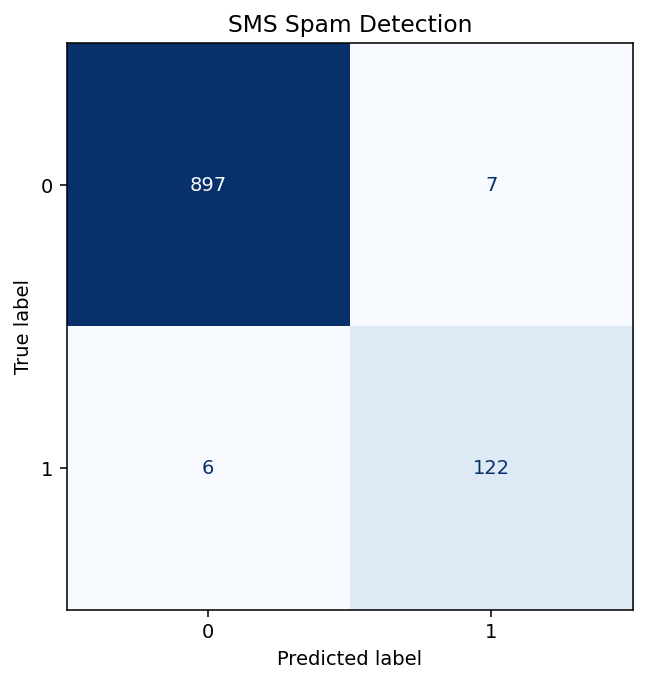

In [7]:
display(pd.DataFrame({"model_test": report["test_metrics"],
                      "dummy_test": report["baseline_metrics"],
                      "model_train": report["training_metrics"]}))
if "classification_report" in report:
    display(pd.DataFrame(report["classification_report"]).T)
output = ROOT / "reports" / PROJECT
save_result(result, output)
display(Image(filename=str(output / "diagnostics.png")))

## 5. Example predictions

These are held-out examples, not a production API. Inference accepts the cleaned feature schema produced by the loader. Inspect the source to understand encoding and feature exclusions.

In [8]:
examples = result["X_test"].iloc[:5]
display(examples)
display(pd.DataFrame({
    "actual": result["y_test"].iloc[:5].to_numpy(),
    "predicted": result["model"].predict(examples),
}))

3616    I to am looking forward to all the sex cuddlin...
1388      I asked sen to come chennai and search for job.
3753                    K...k...when will you give treat?
3868    May b approve panalam...but it should have mor...
2303    One of best dialogue in cute reltnship..!! \We...
Name: message, dtype: string

,actual,predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


## 6. Interpretation and next experiment

Exact repeated messages are removed before splitting. Related templates can still cross partitions; language and campaign drift limit deployment.

Use the confusion matrix or residuals to identify the most costly errors. Before client deployment, verify data rights and feature availability, evaluate an independent population, assess subgroup performance where relevant, and define monitoring and acceptance criteria.

[Project guide](../README.md) · [Portfolio](../../../README.md) · [Evaluation protocol](../../../docs/METHODOLOGY.md)